# SAFE Modeling Results

In [ ]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Attaching package: 'kableExtra'

The following object is masked from 'package:dplyr':

    group_rows


Attaching package: 'gridExtra'

The following object is masked from 'package:dplyr':

    combine

In [ ]:
player_id_map <- read_rds("statcast_data/player_positioning/sc_positioning.rds") |>
  mutate(fielder_id = as.character(fielder_id)) |>
  dplyr::select(fielder_id, name_fielder) |>
  distinct()

safe_results <- read_rds("results/safe_results.rds") |>
  left_join(player_id_map, by = "fielder_id") |>
  rename(fielder_name = name_fielder) |>
  dplyr::select(fielder_id, fielder_name, position, year, n_opportunities, SAFE)

safe_sc_results <- read_rds("results/sc_safe_results.rds") |>
  left_join(player_id_map, by = "fielder_id") |>
  rename(fielder_name = name_fielder) |>
  dplyr::select(fielder_id, fielder_name, position, year, n_opportunities, SAFE)

oaa_drs <- read_rds("statcast_data/oaa_drs.rds") |>
  mutate(fielder_id = as.character(fielder_id))

## Distribution of SAFE Values

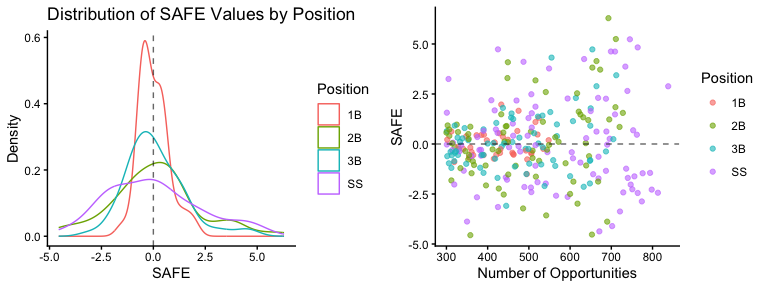

In [ ]:
#| label: fig-safe-distributions
#| fig-cap: "Distribution of SAFE Values by Position"
#| fig-width: 8
#| fig-height: 3

p_safe_dist <- safe_results |>
  ggplot(aes(x = SAFE, color = position)) +
  geom_density() +
  geom_vline(xintercept = 0, linetype = "dashed", color = "black", alpha = 0.6) +
  labs(
    title = "Distribution of SAFE Values by Position",
    x = "SAFE",
    y = "Density",
    color = "Position"
  ) +
  theme_classic()

p_safe_n_opp <- safe_results |>
  ggplot(aes(x = n_opportunities, y = SAFE, color = position)) +
  geom_point(alpha = 0.6) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "black", alpha = 0.6) +
  labs(
    x = "Number of Opportunities",
    y = "SAFE",
    color = "Position"
  ) +
  theme_classic()

grid.arrange(p_safe_dist, p_safe_n_opp, ncol = 2)

## Top 5 By Position for Select Combinations

In [ ]:
top_safe <- function(safe_results, position, year, n = 5) {
  safe_results |>
    filter(position == !!position, year == !!year) |>
    arrange(desc(SAFE)) |>
    slice_head(n = n) |>
    select(fielder_name, SAFE) |>
    mutate(SAFE = round(SAFE, 2))
}

In [ ]:
#| label: tbl-top-ss-2025
#| tbl-cap: "Top 5 Shortstops by SAFE in 2025"

top_safe(safe_results, "SS", 2025) |>
  kable(col.names = c("Fielder", "SAFE")) |>
  kable_styling(full_width = F)

  Fielder             SAFE
  ----------------- ------
  Peña, Jeremy        2.49
  Betts, Mookie       2.27
  Walls, Taylor       2.19
  Volpe, Anthony      1.65
  Witt Jr., Bobby     1.48


In [ ]:
#| label: tbl-top-2b-2025
#| tbl-cap: "Top 5 Second Basemen by SAFE in 2025"

top_safe(safe_results, "2B", 2025) |>
  kable(col.names = c("Fielder", "SAFE")) |>
  kable_styling(full_width = F)

  Fielder            SAFE
  ---------------- ------
  Hoerner, Nico      4.14
  Semien, Marcus     3.18
  Turang, Brice      2.53
  Albies, Ozzie      1.84
  Rengifo, Luis      0.97


In [ ]:
#| label: tbl-top-3b-2025
#| fig-cap: "Top 5 Third Basemen by SAFE in 2025"

top_safe(safe_results, "3B", 2025) |>
  kable(col.names = c("Fielder", "SAFE")) |>
  kable_styling(full_width = F)

In [ ]:
#| label: tbl-top-1b-2024
#| tbl-cap: "Top 5 First Basemen by SAFE in 2024"

top_safe(safe_results, "1B", 2024) |>
  kable(col.names = c("Fielder", "SAFE")) |>
  kable_styling(full_width = F)

  Fielder                SAFE
  -------------------- ------
  Santana, Carlos        0.65
  Torkelson, Spencer     0.62
  Lowe, Nathaniel        0.53
  Goldschmidt, Paul      0.47
  France, Ty             0.46


## Correlation with OAA and DRS

In [ ]:
#| label: tbl-safe-correlations
#| tbl-cap: "Correlation of SAFE with OAA and DRS. Each observation is year-position specific for each fielder."

safe_comparison <- safe_results |>
  inner_join(oaa_drs, by = c("fielder_id", "year", "position"))


safe_comparison |>
  summarize(
    OAA = cor(SAFE, OAA, use = "complete.obs"),
    DRS = cor(SAFE, DRS, use = "complete.obs")
  ) |>
  mutate(metric = "SAFE") |>
  select(metric, everything()) |>
  kable(col.names = c("Metric", "OAA", "DRS")) |>
  kable_styling(full_width = F)

  Metric           OAA         DRS
  -------- ----------- -----------
  SAFE       0.3864817   0.6741958


In [ ]:
#| label: tbl-safe-correlations-by-position
#| tbl-cap: "Correlation of SAFE with OAA and DRS by Position. Each observation is year-position specific for each fielder."

safe_comparison |>
  group_by(position) |>
  summarize(
    OAA = cor(SAFE, OAA, use = "complete.obs"),
    DRS = cor(SAFE, DRS, use = "complete.obs")
  ) |>
  kable(col.names = c("Position", "SAFE-OAA", "SAFE-DRS")) |>
  kable_styling(full_width = F)

  Position      SAFE-OAA    SAFE-DRS
  ---------- ----------- -----------
  1B           0.2908720   0.3526909
  2B           0.5098841   0.7709798
  3B           0.5291908   0.5914008
  SS           0.2764633   0.6987446


## Player-Specific Positioning Results

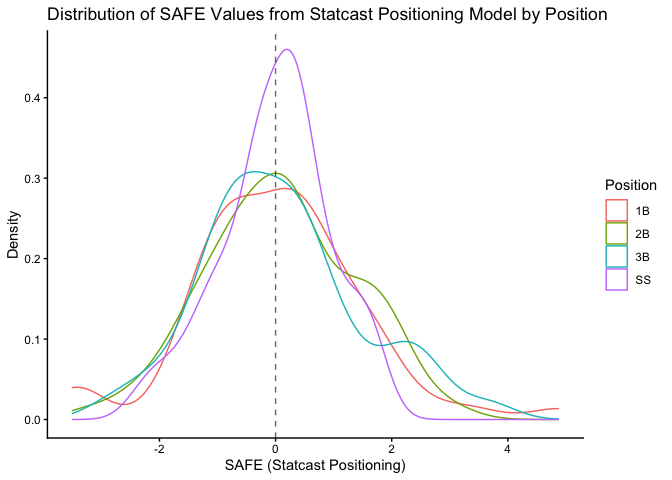

In [ ]:
#| label: fig-safe-sc-distribution
#| fig-cap: "Distribution of SAFE Values from Statcast Positioning Model by Position"

ggplot(safe_sc_results, aes(x = SAFE, color = position)) +
  geom_density() +
  geom_vline(xintercept = 0, linetype = "dashed", color = "black", alpha = 0.6) +
  labs(
    title = "Distribution of SAFE Values from Statcast Positioning Model by Position",
    x = "SAFE (Statcast Positioning)",
    y = "Density",
    color = "Position"
  ) +
  theme_classic()

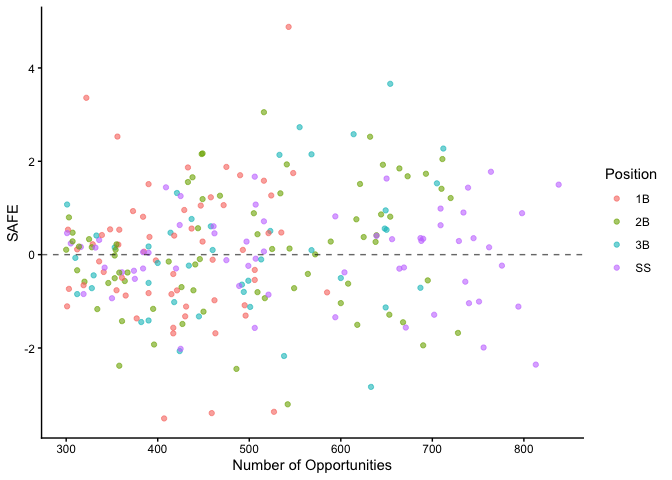

In [ ]:
#| label: fig-safe-sc-n-opportunities
#| fig-cap: "SAFE from Statcast Positioning vs. Number of Opportunities"

safe_sc_results |>
  ggplot(aes(x = n_opportunities, y = SAFE, color = position)) +
  geom_point(alpha = 0.6) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "black", alpha = 0.6) +
  labs(
    x = "Number of Opportunities",
    y = "SAFE",
    color = "Position"
  ) +
  theme_classic()

In [ ]:
#| label: tbl-safe-sc-correlations
#| tbl-cap: "Correlation of SAFE from Statcast Positioning with OAA and DRS. Each observation is year-position specific for each fielder."

safe_sc_comparison <- safe_sc_results |>
  inner_join(oaa_drs, by = c("fielder_id", "year", "position"))

safe_sc_comparison |>
  summarize(
    OAA = cor(SAFE, OAA, use = "complete.obs"),
    DRS = cor(SAFE, DRS, use = "complete.obs")) |>
  mutate(metric = "SAFE (Statcast Positioning)") |>
  select(metric, everything()) |>
  kable(col.names = c("Metric", "OAA", "DRS")) |>
  kable_styling(full_width = F)

  Metric                                OAA         DRS
  ----------------------------- ----------- -----------
  SAFE (Statcast Positioning)     0.3837603   0.6231892


In [ ]:
#| label: tbl-safe-sc-correlations-by-position
#| tbl-cap: "Correlation of SAFE from Statcast Positioning with OAA and DRS by Position. Each observation is year-position specific for each fielder."
safe_sc_comparison |>
  group_by(position) |>
  summarize(
    OAA = cor(SAFE, OAA, use = "complete.obs"),
    DRS = cor(SAFE, DRS, use = "complete.obs")
  ) |>
  kable(col.names = c("Position", "SAFE (Statcast Positioning)-OAA", "SAFE (Statcast Positioning)-DRS")) |>
  kable_styling(full_width = F)

  Position     SAFE (Statcast Positioning)-OAA   SAFE (Statcast Positioning)-DRS
  ---------- --------------------------------- ---------------------------------
  1B                                 0.3863561                         0.6279558
  2B                                 0.3462718                         0.5703947
  3B                                 0.5974199                         0.7369696
  SS                                 0.3702842                         0.6989620
